In [1]:
import os
import tensorflow as tf
import numpy as np
from numpy import expand_dims
import matplotlib.pyplot as plt

#%tensorflow_version 2.x  
from tensorflow.keras.models import Sequential, Model
from tensorflow import keras

from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Activation
from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array

from tensorflow.keras.regularizers import l2




from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession


In [2]:
if tf.test.is_gpu_available():
    print(tf.test.gpu_device_name())
else:
    print("TF cannot find GPU")
tf.__version__  # make sure it's 2.0!

/device:GPU:0


'2.0.0'

In [3]:
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

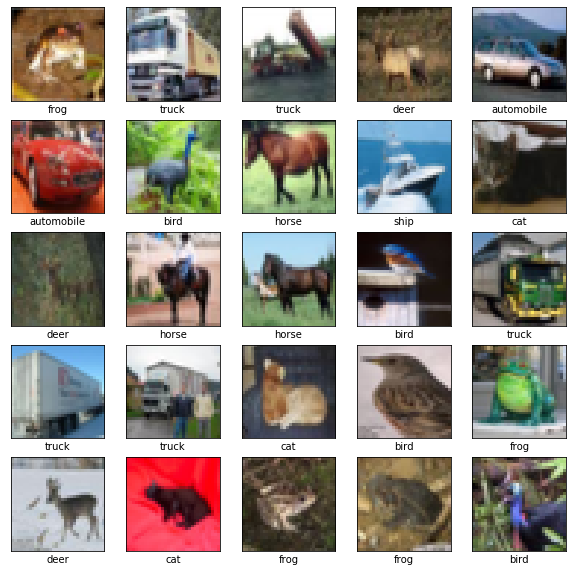

Train data Shape:(50000, 32, 32, 3)
Train label shape:(50000,)


In [4]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels, test_labels = train_labels.reshape((-1,)).astype(np.int32), test_labels.reshape((-1,)).astype(np.int32)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i]])
plt.show()

print("Train data Shape:"+ str(train_images.shape)) #50000 images of 32X32 pixels 3 channels(RGB)
print("Train label shape:"+ str(train_labels.shape))
# data = tf.data.Dataset.from_tensor_slices(
#     (train_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, train_labels.reshape((-1,)).astype(np.int32)))
# data = data.shuffle(buffer_size=50000).batch(128).repeat()

# # note: we batch the test data, but do not shuffle/repeat
# test_data = tf.data.Dataset.from_tensor_slices(
#     (test_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, test_labels.reshape((-1,)).astype(np.int32))).batch(128)


In [5]:
def plotLosses(history):  
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [6]:
def plotAccuracies(history):  
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.5, 1])
    plt.legend(loc='upper right')
    plt.show()

# DenseNet Model Definiton


In [27]:
def conv_factory(x, concat_axis, nb_filter,
                 dropout_rate=None, weight_decay=1E-4):
    #Apply BatchNorm, Relu 3x3Conv2D, optional dropout

    x1 = BatchNormalization(axis=concat_axis,
                           gamma_regularizer=l2(weight_decay),
                           beta_regularizer=l2(weight_decay))(x)
    x1 = Activation('relu')(x1)
    x1 = Conv2D(nb_filter, (3, 3),
               kernel_initializer="he_uniform",
               activation=tf.nn.relu,
               padding="same",
               use_bias=False,
               kernel_regularizer=l2(weight_decay))(x1)
    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    x = Concatenate(axis=concat_axis)([x, x1])
    return x

In [23]:
def transition(x, concat_axis, nb_filter,
               dropout_rate=None, weight_decay=1E-4):
    #Apply BatchNorm, Relu 1x1Conv2D, optional dropout and Maxpooling2D

    x = BatchNormalization(axis=concat_axis,
                           gamma_regularizer=l2(weight_decay),
                           beta_regularizer=l2(weight_decay))(x)
    x = Activation('relu')(x)
    x = Conv2D(nb_filter, (1, 1),
               kernel_initializer="he_uniform",
               padding="same",
               use_bias=False,
               kernel_regularizer=l2(weight_decay))(x)
    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

    return x


In [24]:
def denseblock(x, concat_axis, nb_layers, nb_filter, growth_rate,
               dropout_rate=None, weight_decay=1E-4):
    #Build a denseblock where the output of each conv_factory is fed to subsequent ones
       
    for num in range(nb_layers):
        x = conv_factory(x, concat_axis, nb_filter,
                         dropout_rate, weight_decay)
    nb_filter += growth_rate

    return x, nb_filter

In [40]:
def DenseNet(nb_classes, img_dim, nb_layers, nb_dense_block, growth_rate,
             nb_filter, dropout_rate=None, weight_decay=1E-4):
    #Build the DenseNet model
  
    if tf.keras.backend.image_data_format() == "channels first":
        concat_axis = 1
    else:
        concat_axis = -1

    model_input = tf.keras.layers.Input((img_dim))

    # Initial convolution
    x = Conv2D(nb_filter, (3, 3),
               kernel_initializer="he_uniform",
               padding="same",
               name="initial_conv2D",
               use_bias=False,
               kernel_regularizer=l2(weight_decay))(model_input)

    # Add dense blocks
    for block_idx in range(nb_dense_block - 1):
        x, nb_filter = denseblock(x, concat_axis, nb_layers,
                                  nb_filter, growth_rate, 
                                  dropout_rate=dropout_rate,
                                  weight_decay=weight_decay)
        # add transition
        x = transition(x, concat_axis, nb_filter, dropout_rate=dropout_rate,
                       weight_decay=weight_decay)

    # The last denseblock does not have a transition
    x, nb_filter = denseblock(x, concat_axis, nb_layers,
                              nb_filter, growth_rate, 
                              dropout_rate=dropout_rate,
                              weight_decay=weight_decay)

    x = BatchNormalization(axis=concat_axis,
                           gamma_regularizer=l2(weight_decay),
                           beta_regularizer=l2(weight_decay))(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D(data_format=tf.keras.backend.image_data_format())(x)
    #x = Dropout(0.5)(x) //
    x = Dense(nb_classes,
              activation='softmax',
              kernel_regularizer=l2(weight_decay),
              bias_regularizer=l2(weight_decay))(x)

    densenet = Model(inputs=[model_input], outputs=[x], name="DenseNet")

    return densenet

# Model_implementation

In [36]:
batch_size=64
epochs=100
nb_classes=10
nb_layers=5 #number of layers in a dense block
nb_dense_block=3 #number of dense blocks
nb_filter=32 #number of filters
growth_rate=32 #growth rate increases the number of filters per layer
dropout_rate=0.2 #dropout rate in the dense blocks
learning_rate=0.1 
weight_decay=1E-4 
img_dim = train_images.shape[1:]

model = DenseNet( nb_classes,
                  img_dim,
                  nb_layers,
                  nb_dense_block,
                  growth_rate,
                  nb_filter,
                  dropout_rate=dropout_rate,
                  weight_decay=weight_decay)

In [33]:
model.summary()

Model: "DenseNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 32, 32, 3)]  0                                            
__________________________________________________________________________________________________
initial_conv2D (Conv2D)         (None, 32, 32, 32)   864         input_6[0][0]                    
__________________________________________________________________________________________________
batch_normalization_41 (BatchNo (None, 32, 32, 32)   128         initial_conv2D[0][0]             
__________________________________________________________________________________________________
activation_39 (Activation)      (None, 32, 32, 32)   0           batch_normalization_41[0][0]     
___________________________________________________________________________________________

In [38]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


Train on 50000 samples, validate on 10000 samples
Epoch 1/100
50000/50000 [==============================] - 77s 2ms/sample - loss: 2.0095 - accuracy: 0.4760 - val_loss: 1.7252 - val_accuracy: 0.5690
Epoch 2/100
50000/50000 [==============================] - 69s 1ms/sample - loss: 1.4361 - accuracy: 0.6603 - val_loss: 1.5081 - val_accuracy: 0.6325
Epoch 3/100
50000/50000 [==============================] - 69s 1ms/sample - loss: 1.1860 - accuracy: 0.7377 - val_loss: 1.1674 - val_accuracy: 0.7315
Epoch 4/100
50000/50000 [==============================] - 69s 1ms/sample - loss: 1.0472 - accuracy: 0.7762 - val_loss: 1.0826 - val_accuracy: 0.7685
Epoch 5/100
50000/50000 [==============================] - 69s 1ms/sample - loss: 0.9533 - accuracy: 0.8060 - val_loss: 1.0974 - val_accuracy: 0.7559
Epoch 6/100
50000/50000 [==============================] - 69s 1ms/sample - loss: 0.8898 - accuracy: 0.8232 - val_loss: 1.0245 - val_accuracy: 0.7752
Epoch 7/100
50000/50000 [=========================

Epoch 55/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4687 - accuracy: 0.9425 - val_loss: 1.0283 - val_accuracy: 0.8027
Epoch 56/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4659 - accuracy: 0.9422 - val_loss: 0.8018 - val_accuracy: 0.8407
Epoch 57/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4685 - accuracy: 0.9425 - val_loss: 0.7782 - val_accuracy: 0.8577
Epoch 58/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4639 - accuracy: 0.9428 - val_loss: 0.7379 - val_accuracy: 0.8621
Epoch 59/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4637 - accuracy: 0.9428 - val_loss: 0.9237 - val_accuracy: 0.8247
Epoch 60/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4627 - accuracy: 0.9433 - val_loss: 0.7746 - val_accuracy: 0.8534
Epoch 61/100
50000/50000 [==============================] - 67s 1ms/sample - loss: 0.4591 - ac

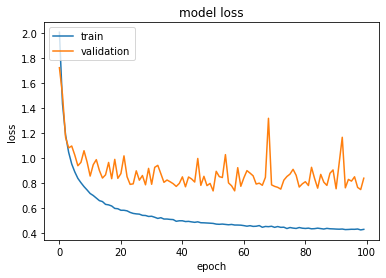

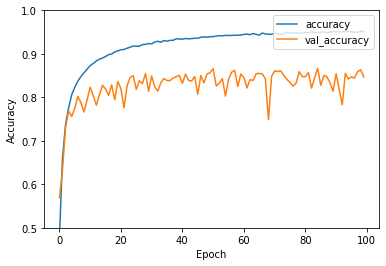

In [39]:
history = model.fit(train_images, train_labels,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(test_images, test_labels),
                    shuffle=True)
plotLosses(history)
plotAccuracies(history)

With the current parameters the loss is still relatively high. 

In [47]:
batch_size=256
epochs=50
nb_classes=10
nb_layers=5
nb_dense_block=3
nb_filter=32
growth_rate=32
dropout_rate=0.2
learning_rate=0.1
weight_decay=1E-4
img_dim = train_images.shape[1:]

model = DenseNet( nb_classes,
                  img_dim,
                  nb_layers,
                  nb_dense_block,
                  growth_rate,
                  nb_filter,
                  dropout_rate=dropout_rate,
                  weight_decay=weight_decay)

Train on 50000 samples, validate on 10000 samples
Epoch 1/50
50000/50000 [==============================] - 69s 1ms/sample - loss: 2.0175 - accuracy: 0.4834 - val_loss: 3.0003 - val_accuracy: 0.2062
Epoch 2/50
50000/50000 [==============================] - 61s 1ms/sample - loss: 1.4931 - accuracy: 0.6680 - val_loss: 1.9274 - val_accuracy: 0.5205
Epoch 3/50
50000/50000 [==============================] - 61s 1ms/sample - loss: 1.2484 - accuracy: 0.7445 - val_loss: 1.4581 - val_accuracy: 0.6774
Epoch 4/50
50000/50000 [==============================] - 61s 1ms/sample - loss: 1.0909 - accuracy: 0.7906 - val_loss: 1.3202 - val_accuracy: 0.7110
Epoch 5/50
50000/50000 [==============================] - 61s 1ms/sample - loss: 0.9834 - accuracy: 0.8169 - val_loss: 1.2892 - val_accuracy: 0.7129
Epoch 6/50
50000/50000 [==============================] - 61s 1ms/sample - loss: 0.9001 - accuracy: 0.8407 - val_loss: 1.3725 - val_accuracy: 0.6775
Epoch 7/50
50000/50000 [==============================] 

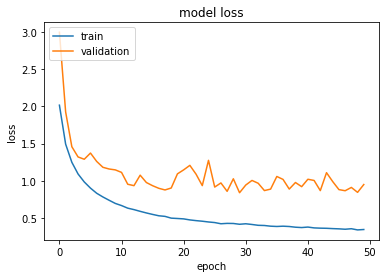

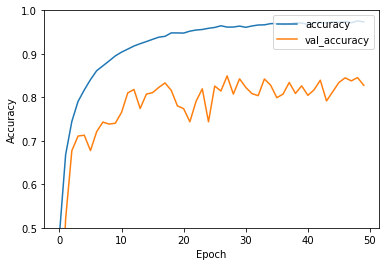

In [48]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history = model.fit(train_images, train_labels,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(test_images, test_labels),
                    shuffle=True)
plotLosses(history)
plotAccuracies(history)

Picture below shows that there is still room for improvement, f.e. by
-adding another conv_layer in the conv_factory
-building deeper models
-changing the learning rate after a certain number of epochs


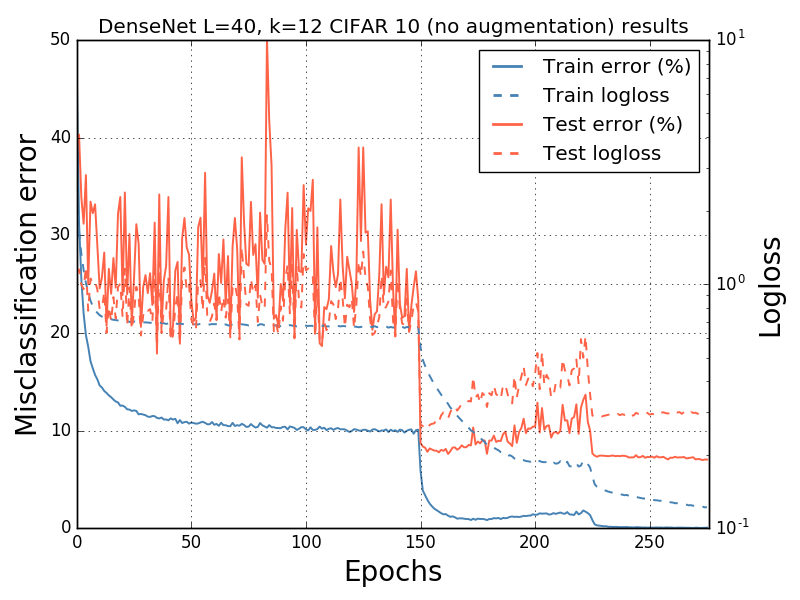